# Сравнение PINN vs МКР

## 0. Подготовка

In [ ]:
import sys
from pathlib import Path


sys.path.insert(0, '.')
sys.path.insert(0, 'problems')

import numpy as np
import torch
import matplotlib.pyplot as plt

from pinn_core import PINNSolver, set_seed

from runner import run_task, print_summary_table
from viz import (plot_compare_2d, plot_compare_2d_t_snapshots,
                 plot_loss_history)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', DEVICE)

set_seed(42)

PLOTS = Path('outputs')
PLOTS.mkdir(exist_ok=True)


all_results = []

def collect_row(result, label):
    ev = result.get('eval', {})
    all_results.append({
        'name': label,
        'fdm_err': ev.get('fdm_err'),
        'fdm_time': result['fdm']['time'] if result.get('fdm') else 0.0,
        'pinn_err': ev.get('pinn_err'),
        'pinn_time': result['pinn']['time'] if result.get('pinn') else 0.0,
    })

PINN Solver loaded
Устройство: cuda


## 1. Параболика

Задача 2 — диффузия с неоднородными Дирихле, простейшая.

Задача 4 — нестационарный Нейман на обоих концах: проверка обработки потоков.

Задача 9 — конвекция-диффузия + Робен: самая богатая ГУ-структурой.


  ЛР1 №2: диффузия + неодн. Дирихле
  PDE: u_t = a u_xx,  u(0,t)=0, u(1,t)=1, u(x,0)=x+sin(πx)
--- МКР ---
  МКР-параболика: nx=101, nt=1001, h=0.01, τ=0.001, схема=crank_nicolson, upwind=False
  МКР время: 0.14s
--- PINN ---
Adam (4000 ep, lr=0.001, coll=1500 random)


Adam:   0%|          | 0/4000 [00:00<?, ?it/s]c:\Users\NikitoZ\miniconda3\envs\pinn\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Adam:  50%|█████     | 2013/4000 [00:32<00:30, 64.51it/s]

   2000 | L=9.13e-04 | res=6.60e-04 | cond=2.54e-05


Adam: 100%|██████████| 4000/4000 [01:02<00:00, 63.72it/s]


   4000 | L=3.50e-04 | res=2.69e-04 | cond=8.13e-06
L-BFGS (max 1500)
  L-BFGS   200 | L=3.42e-05
  L-BFGS   400 | L=3.32e-06
  L-BFGS   600 | L=3.32e-06
Done 84.3s | res=2.57e-06 | cond=7.43e-08 | total=3.32e-06
  PINN время: 84.32s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 3.250e-05   Max |Δ|: 9.844e-05
  PINN:   Rel L2: 1.143e-04   Max |Δ|: 4.320e-04


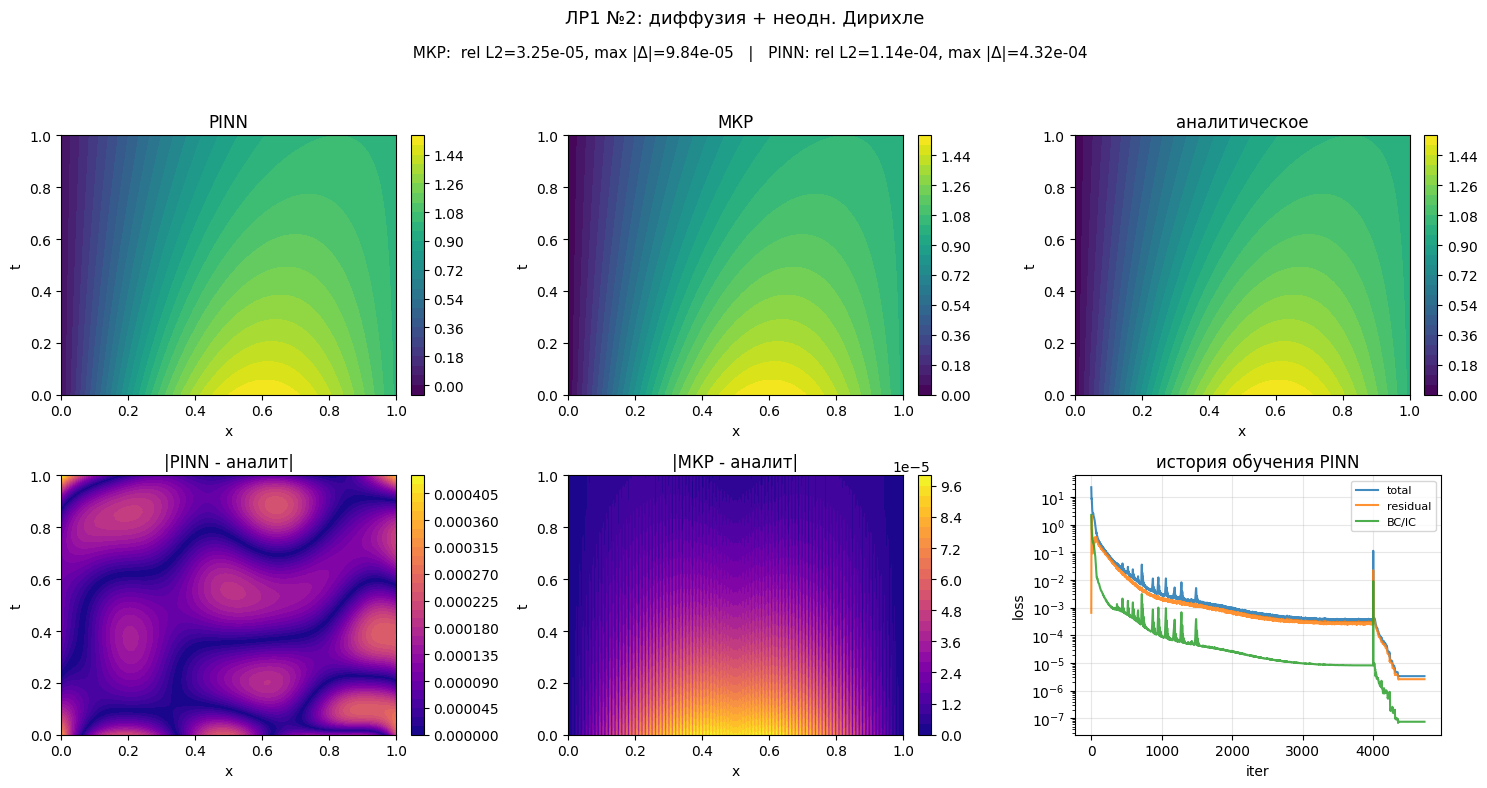


  ЛР1 №4: диффузия + нестац. Нейман
  PDE: u_t = a u_xx, u_x(0,t)=exp(-at), u_x(π,t)=-exp(-at), u(x,0)=sin x
--- МКР ---
  МКР-параболика: nx=101, nt=2001, h=0.03142, τ=0.001, схема=crank_nicolson, upwind=False
  МКР время: 0.94s
--- PINN ---
Adam (5000 ep, lr=0.001, coll=2000 random)


Adam:  40%|████      | 2008/5000 [00:37<00:51, 57.64it/s]

   2000 | L=2.75e-04 | res=1.60e-04 | cond=7.66e-06


Adam:  80%|████████  | 4007/5000 [01:14<00:17, 55.37it/s]

   4000 | L=9.20e-05 | res=6.16e-05 | cond=2.02e-06


Adam: 100%|██████████| 5000/5000 [01:35<00:00, 52.58it/s]


L-BFGS (max 1500)
  L-BFGS   200 | L=6.32e-06
  L-BFGS   400 | L=1.38e-06
  L-BFGS   600 | L=1.38e-06
Done 115.4s | res=1.09e-06 | cond=1.96e-08 | total=1.38e-06
  PINN время: 115.46s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 2.208e-04   Max |Δ|: 2.356e-04
  PINN:   Rel L2: 3.224e-04   Max |Δ|: 4.295e-04


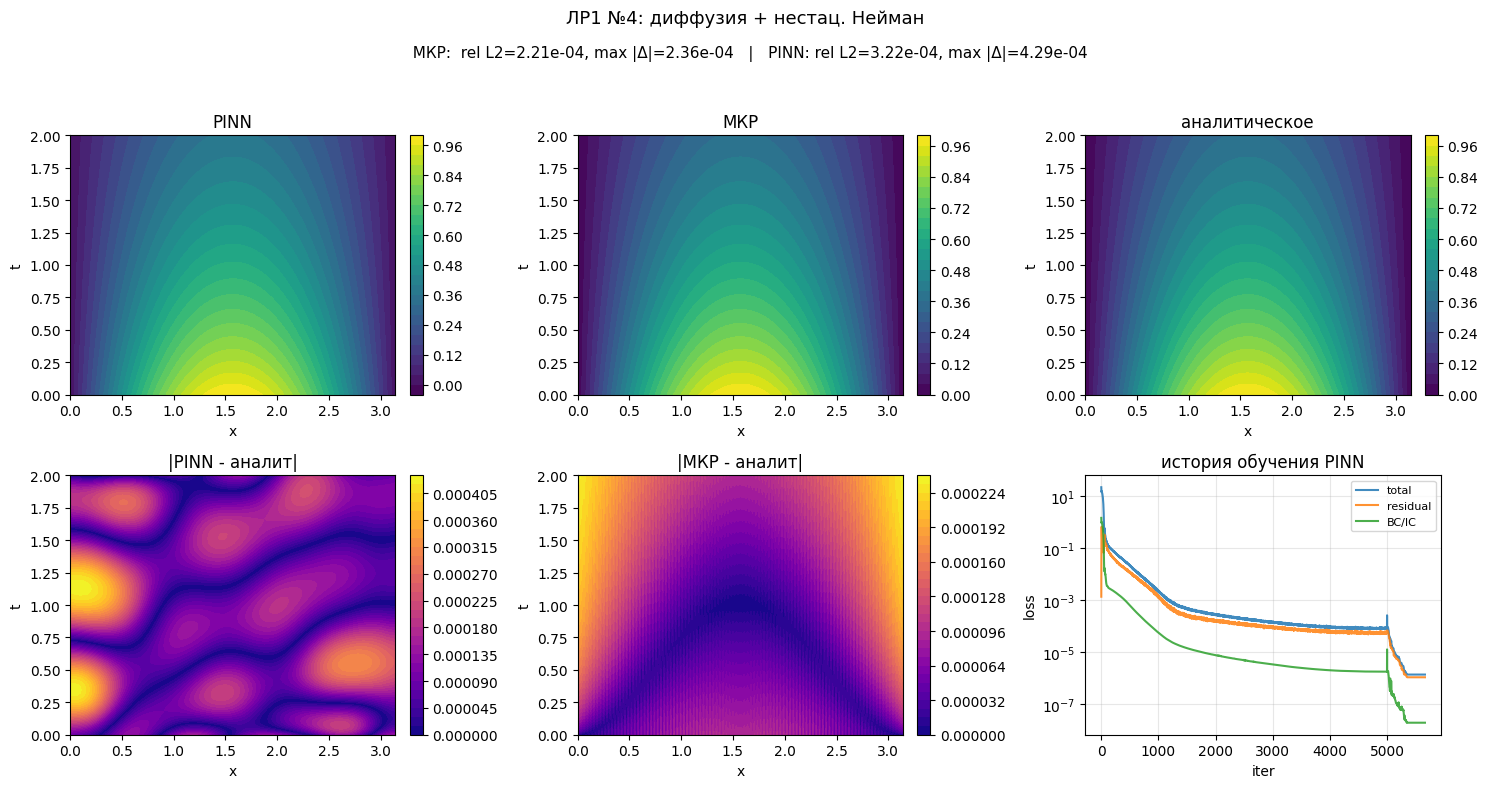


  ЛР1 №9: конвекция-диффузия + Робен
  PDE: u_t = a u_xx + b u_x, u_x(0,t)-u(0,t)=-exp(-at)(cos bt+sin bt), u_x(π,t)-u(π,t)= exp(-at)(cos bt+sin bt), u(x,0)=cos x
--- МКР ---
  МКР-параболика: nx=151, nt=2001, h=0.02094, τ=0.001, схема=crank_nicolson, upwind=False
  МКР время: 1.08s
--- PINN ---
Adam (7000 ep, lr=0.001, coll=3000 random)


Adam:  29%|██▊       | 2004/7000 [01:10<02:54, 28.62it/s]

   2000 | L=6.04e-05 | res=1.94e-05 | cond=2.70e-05


Adam:  57%|█████▋    | 4003/7000 [02:19<01:43, 28.95it/s]

   4000 | L=1.62e-05 | res=2.47e-06 | cond=7.84e-06


Adam:  86%|████████▌ | 6004/7000 [03:28<00:36, 27.00it/s]

   6000 | L=1.04e-05 | res=1.29e-06 | cond=5.82e-06


Adam: 100%|██████████| 7000/7000 [04:02<00:00, 28.82it/s]


L-BFGS (max 1500)
  L-BFGS   200 | L=1.15e-05
Done 257.0s | res=1.62e-06 | cond=5.75e-06 | total=1.15e-05
  PINN время: 257.02s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 4.490e-04   Max |Δ|: 1.440e-03
  PINN:   Rel L2: 3.786e-02   Max |Δ|: 1.084e-01


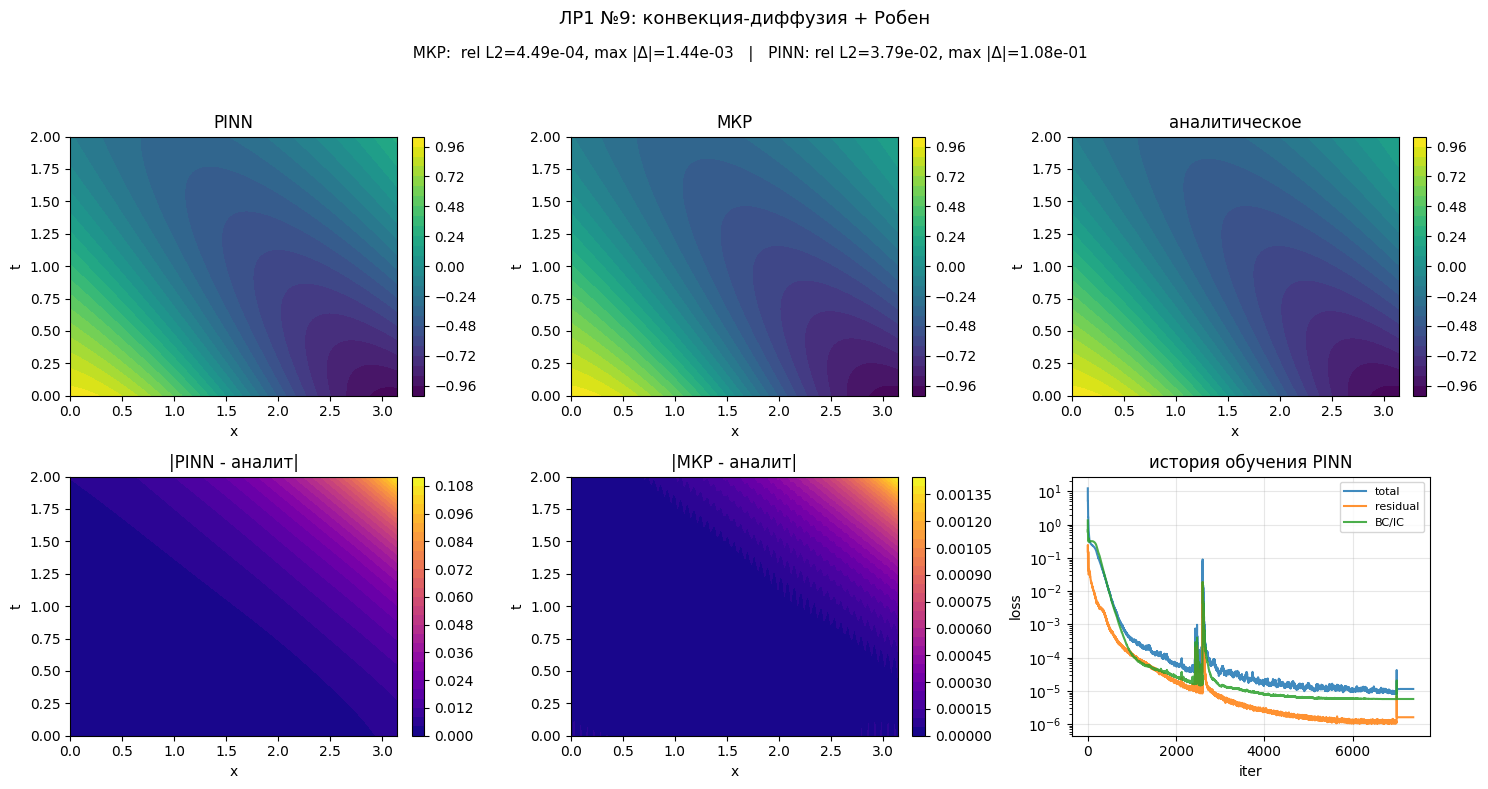

In [2]:
from problems.lr1_parabolic_1d import LR1_TASKS

lr1_results = []
for task in LR1_TASKS:
    res = run_task(task, kind='parabolic_1d',
                   PINNSolver_cls=PINNSolver, device=DEVICE,
                   eval_n=200, verbose=True)
    lr1_results.append(res)
    collect_row(res, task['name'])
    plot_compare_2d(res, save_to=PLOTS / f"lr1_{task['name'][4:6].strip().replace(' ','_')}.png")

## 2. Гиперболика

Задача 2 — волновое + однородный Робен.

Задача 3 — Клейн–Гордон с нестационарным Дирихле.

Задача 8 — телеграфное (демпфированное волновое + конвекция + реакция).


  ЛР2 №2: волновое + Робен (α=-1, β=1)
  PDE: u_tt = a² u_xx, u_x-u=0 на обоих концах
--- МКР ---
  МКР-гиперболика: nx=201, nt=4001, h=0.01571, τ=0.0007854, CFL=0.050, d=0.0, b=0.0, c=0.0
  МКР время: 0.08s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=3000 random)


Adam:  25%|██▌       | 2003/8000 [01:33<04:42, 21.24it/s]

   2000 | L=5.61e-04 | res=4.78e-05 | cond=5.23e-04


Adam:  50%|█████     | 4002/8000 [03:09<02:53, 23.01it/s]

   4000 | L=1.62e-04 | res=1.09e-05 | cond=1.64e-04


Adam:  75%|███████▌  | 6003/8000 [04:40<01:25, 23.28it/s]

   6000 | L=9.51e-05 | res=3.49e-06 | cond=1.17e-04


Adam: 100%|██████████| 8000/8000 [06:10<00:00, 21.62it/s]


   8000 | L=1.54e-04 | res=1.84e-06 | cond=1.20e-04
L-BFGS (max 2500)
  L-BFGS   200 | L=1.67e-04
  L-BFGS   400 | L=1.67e-04
  L-BFGS   600 | L=1.67e-04
Done 398.1s | res=2.21e-06 | cond=1.19e-04 | total=1.67e-04
  PINN время: 398.13s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 5.612e-05   Max |Δ|: 1.211e-04
  PINN:   Rel L2: 7.824e-02   Max |Δ|: 4.941e-01


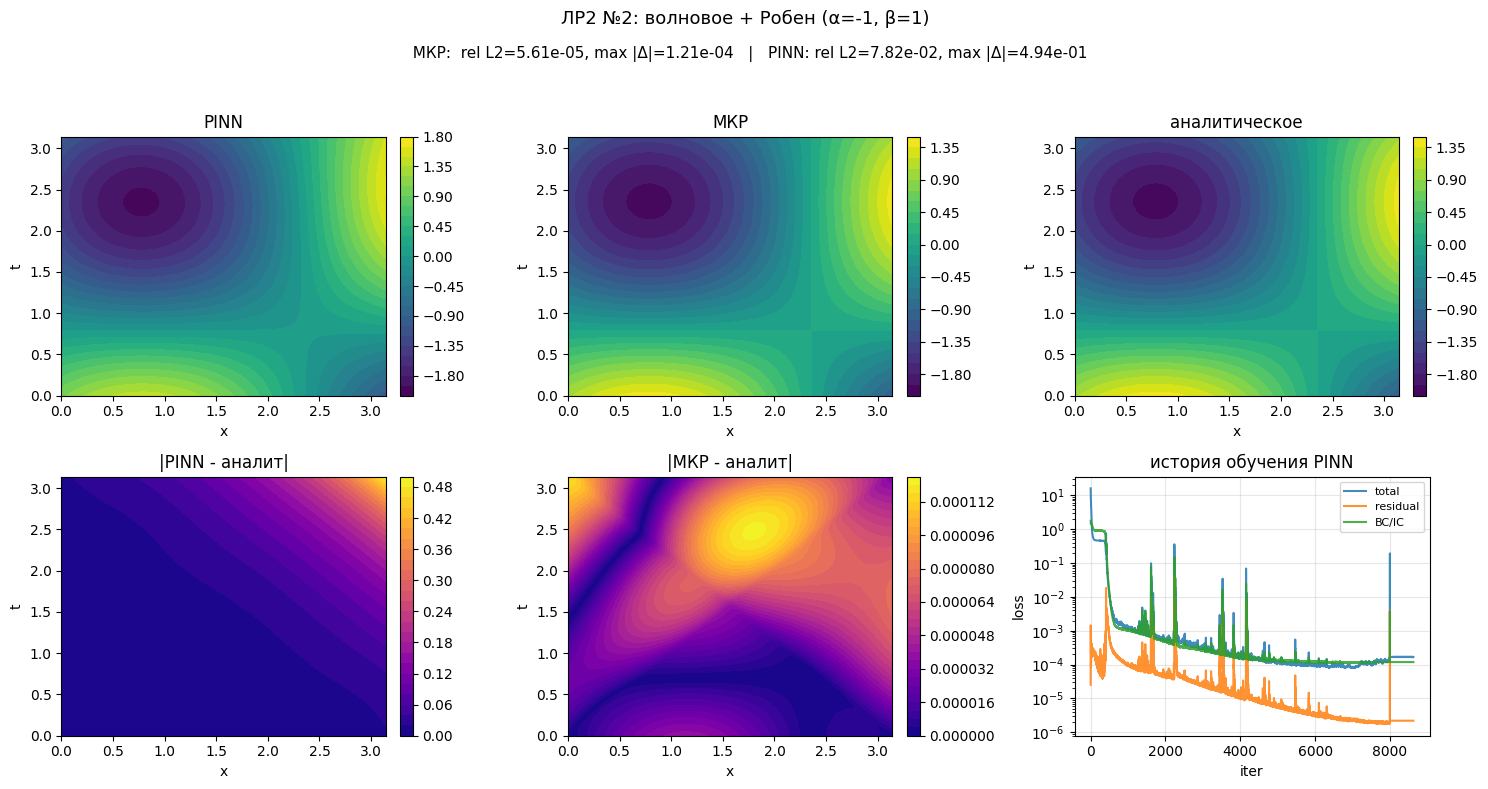


  ЛР2 №3: Клейн–Гордон + нестац. Дирихле
  PDE: u_tt = u_xx - 3u, u(0,t)=sin(2t), u(π,t)=-sin(2t)
--- МКР ---
  МКР-гиперболика: nx=201, nt=4001, h=0.01571, τ=0.0007854, CFL=0.050, d=0.0, b=0.0, c=-3.0
  МКР время: 0.08s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=3000 random)


Adam:  25%|██▌       | 2003/8000 [01:15<04:01, 24.86it/s]

   2000 | L=1.16e-02 | res=9.33e-03 | cond=2.43e-03


Adam:  50%|█████     | 4004/8000 [02:30<02:27, 27.08it/s]

   4000 | L=3.61e-04 | res=3.89e-04 | cond=4.58e-05


Adam:  75%|███████▌  | 6002/8000 [03:44<01:13, 27.22it/s]

   6000 | L=1.85e-04 | res=2.19e-04 | cond=1.25e-05


Adam: 100%|██████████| 8000/8000 [04:59<00:00, 26.71it/s]


   8000 | L=1.72e-04 | res=2.19e-04 | cond=5.17e-06
L-BFGS (max 2500)
  L-BFGS   200 | L=1.95e-04
  L-BFGS   400 | L=1.95e-04
  L-BFGS   600 | L=1.95e-04
Done 332.0s | res=2.82e-04 | cond=5.03e-06 | total=1.95e-04
  PINN время: 332.03s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 1.306e-05   Max |Δ|: 1.471e-05
  PINN:   Rel L2: 3.833e-03   Max |Δ|: 6.679e-03


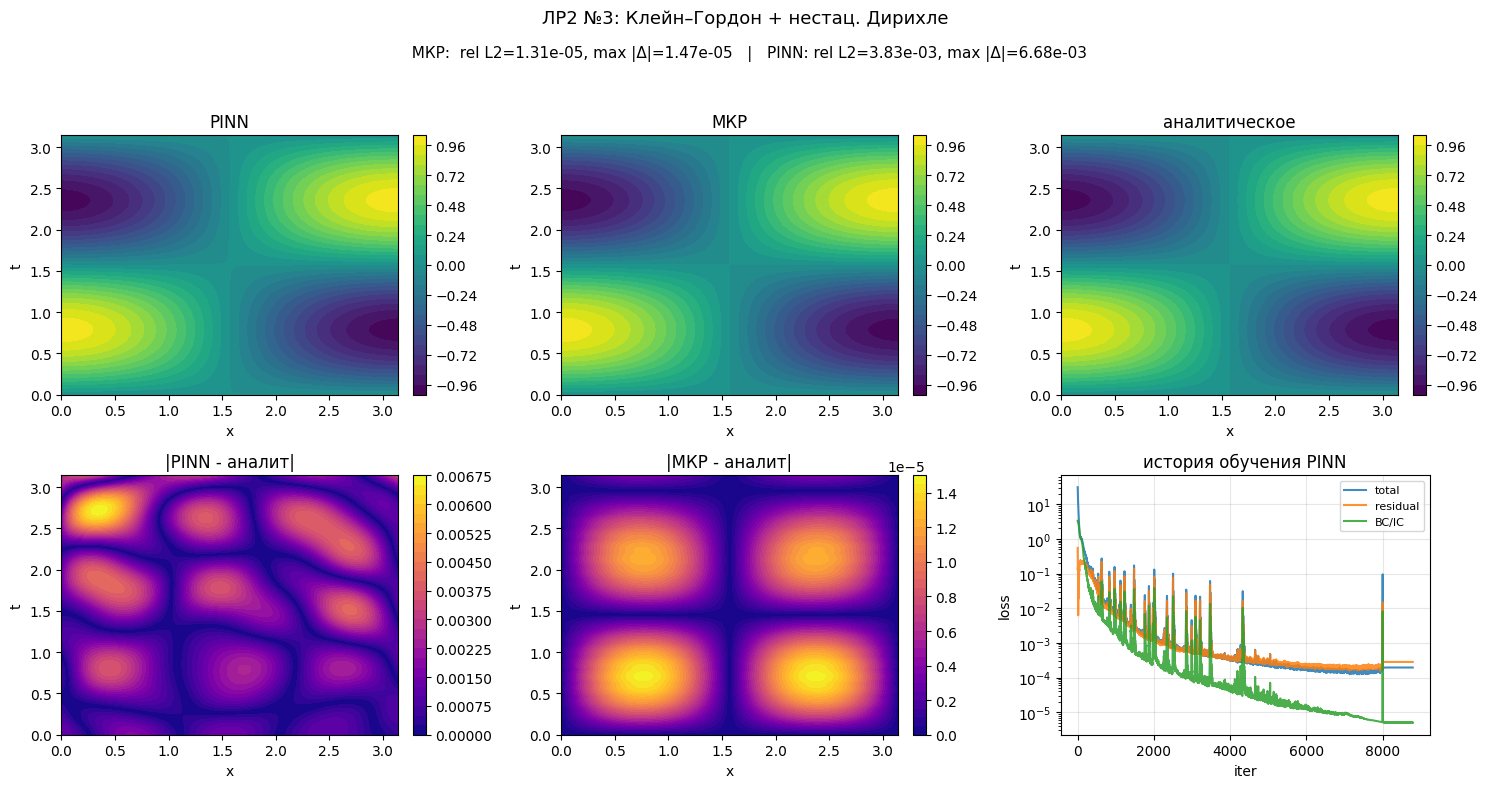


  ЛР2 №8: телеграфное (свободные затух. колебания)
  PDE: u_tt + 2u_t = u_xx + 2u_x − 3u, однор. Дирихле
--- МКР ---
  МКР-гиперболика: nx=201, nt=4001, h=0.01571, τ=0.0007854, CFL=0.050, d=2.0, b=2.0, c=-3.0
  МКР время: 0.07s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=3000 random)


Adam:  25%|██▌       | 2003/8000 [01:26<04:21, 22.95it/s]

   2000 | L=1.82e-04 | res=1.78e-04 | cond=2.64e-05


Adam:  50%|█████     | 4002/8000 [02:55<02:54, 22.87it/s]

   4000 | L=6.66e-05 | res=6.00e-05 | cond=1.28e-05


Adam:  75%|███████▌  | 6003/8000 [04:21<01:25, 23.30it/s]

   6000 | L=3.03e-05 | res=2.65e-05 | cond=6.14e-06


Adam: 100%|██████████| 8000/8000 [05:51<00:00, 22.74it/s]


   8000 | L=4.17e-05 | res=2.39e-05 | cond=3.77e-06
L-BFGS (max 2500)
  L-BFGS   200 | L=3.72e-05
  L-BFGS   400 | L=3.72e-05
  L-BFGS   600 | L=3.72e-05
Done 388.4s | res=3.48e-05 | cond=3.52e-06 | total=3.72e-05
  PINN время: 388.39s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 3.777e-05   Max |Δ|: 7.050e-06
  PINN:   Rel L2: 1.664e-02   Max |Δ|: 5.090e-03


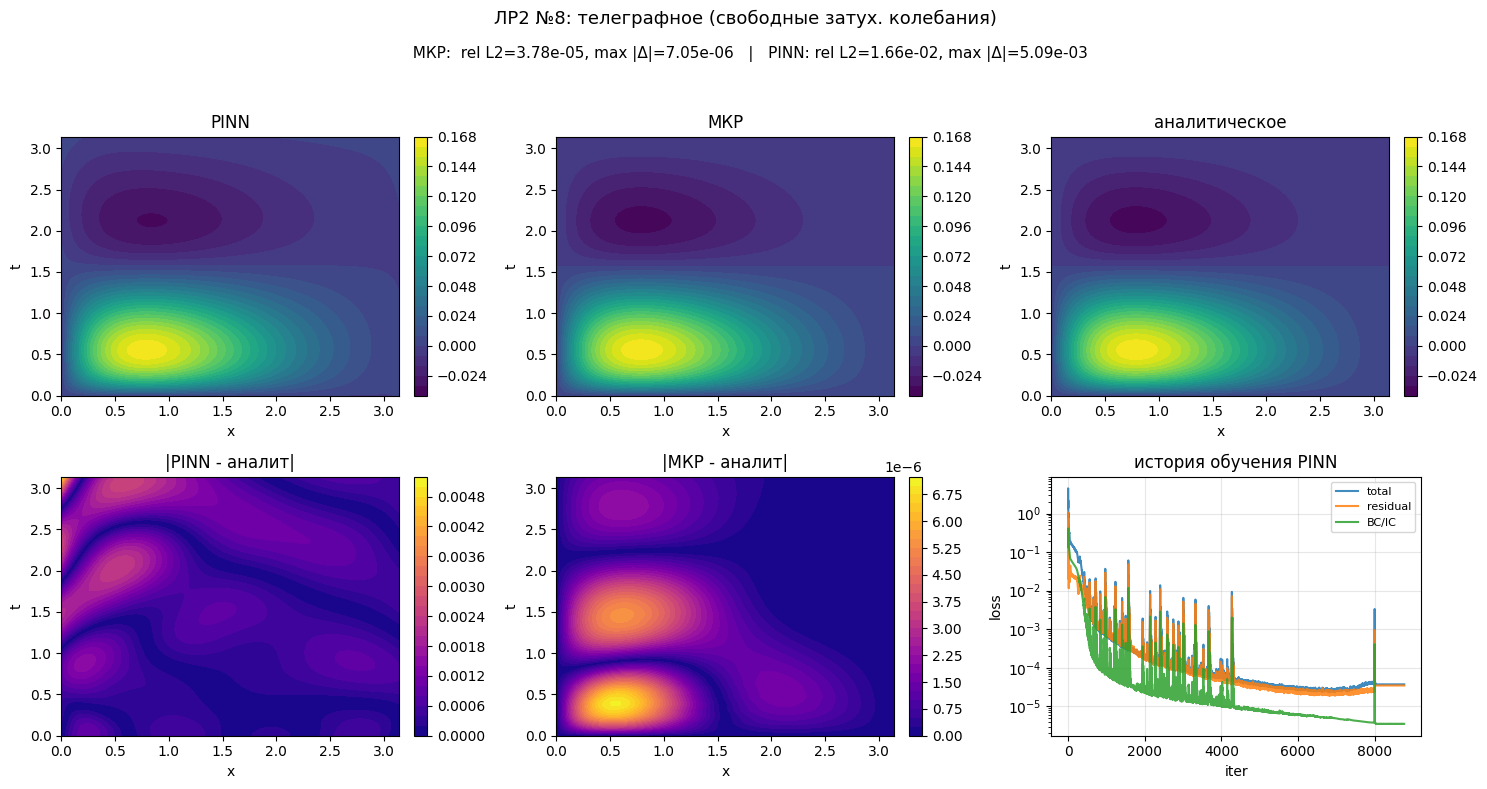

In [3]:
from problems.lr2_hyperbolic_1d import LR2_TASKS

lr2_results = []
for task in LR2_TASKS:
    res = run_task(task, kind='hyperbolic_1d',
                   PINNSolver_cls=PINNSolver, device=DEVICE,
                   eval_n=200, verbose=True)
    lr2_results.append(res)
    collect_row(res, task['name'])
    plot_compare_2d(res, save_to=PLOTS / f"lr2_{task['name'][4:6].strip().replace(' ','_')}.png")

## 3. Эллиптика 2D

Задача 2 — Лаплас + смешанные ГУ (Нейман+Дирихле). На квадратичном решении МКР даёт машинный ноль.

Задача 7 — Гельмгольц $\Delta u + 2u = 0$, чисто Дирихле.

Задача 10 — полное эллиптическое уравнение конвекции-диффузии-реакции.


  ЛР3 №2: Лаплас + смешанные ГУ, U=x²-y²
  PDE: Δu = 0,  u_x(0,y)=0, u(1,y)=1-y², u_y(x,0)=0, u(x,1)=x²-1
--- МКР ---
  МКР-эллиптика: nx=51, ny=51, hx=0.02, hy=0.02
  МКР время: 0.07s
--- PINN ---
Adam (5000 ep, lr=0.001, coll=2000 random)


Adam:  40%|████      | 2004/5000 [00:46<01:10, 42.54it/s]

   2000 | L=1.74e-03 | res=1.56e-03 | cond=1.16e-05


Adam:  80%|████████  | 4005/5000 [01:32<00:23, 41.47it/s]

   4000 | L=9.99e-04 | res=9.41e-04 | cond=3.91e-06


Adam: 100%|██████████| 5000/5000 [01:56<00:00, 43.02it/s]


L-BFGS (max 1500)
  L-BFGS   200 | L=5.13e-05
  L-BFGS   400 | L=2.06e-05
  L-BFGS   600 | L=1.14e-05
  L-BFGS   800 | L=7.10e-06
  L-BFGS  1000 | L=5.40e-06
  L-BFGS  1200 | L=4.36e-06
Done 169.5s | res=4.13e-06 | cond=1.51e-08 | total=4.36e-06
  PINN время: 169.53s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 1.005e-04   Max |Δ|: 1.000e-04
  PINN:   Rel L2: 5.349e-05   Max |Δ|: 1.028e-04


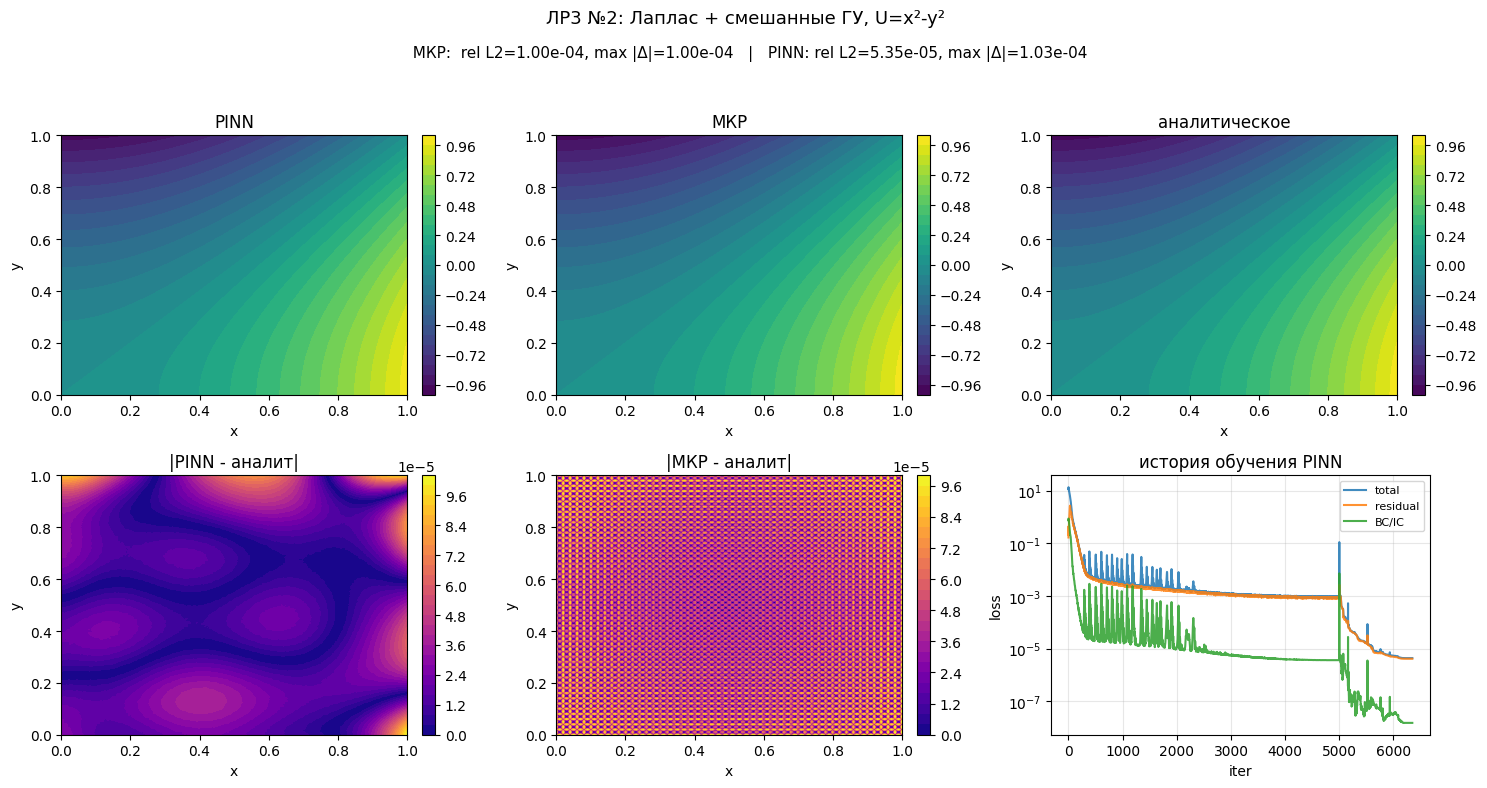


  ЛР3 №7: Гельмгольц Δu+2u=0, U=cos x · cos y
  PDE: Δu + 2u = 0, чисто Дирихле
--- МКР ---
  МКР-эллиптика: nx=51, ny=51, hx=0.03142, hy=0.03142
  МКР время: 0.08s
--- PINN ---
Adam (6000 ep, lr=0.001, coll=2500 random)


Adam:  33%|███▎      | 2002/6000 [01:10<02:24, 27.60it/s]

   2000 | L=1.28e-04 | res=7.30e-05 | cond=4.07e-05


Adam:  67%|██████▋   | 4004/6000 [02:22<01:11, 27.77it/s]

   4000 | L=2.29e-05 | res=1.43e-05 | cond=3.90e-06


Adam: 100%|██████████| 6000/6000 [03:31<00:00, 28.36it/s]


   6000 | L=1.32e-05 | res=1.04e-05 | cond=2.32e-06
L-BFGS (max 1800)
  L-BFGS   200 | L=1.43e-05
  L-BFGS   400 | L=1.43e-05
Done 230.2s | res=1.14e-05 | cond=2.34e-06 | total=1.39e-05
  PINN время: 230.27s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 1.567e-04   Max |Δ|: 2.466e-04
  PINN:   Rel L2: 7.788e-04   Max |Δ|: 1.882e-03


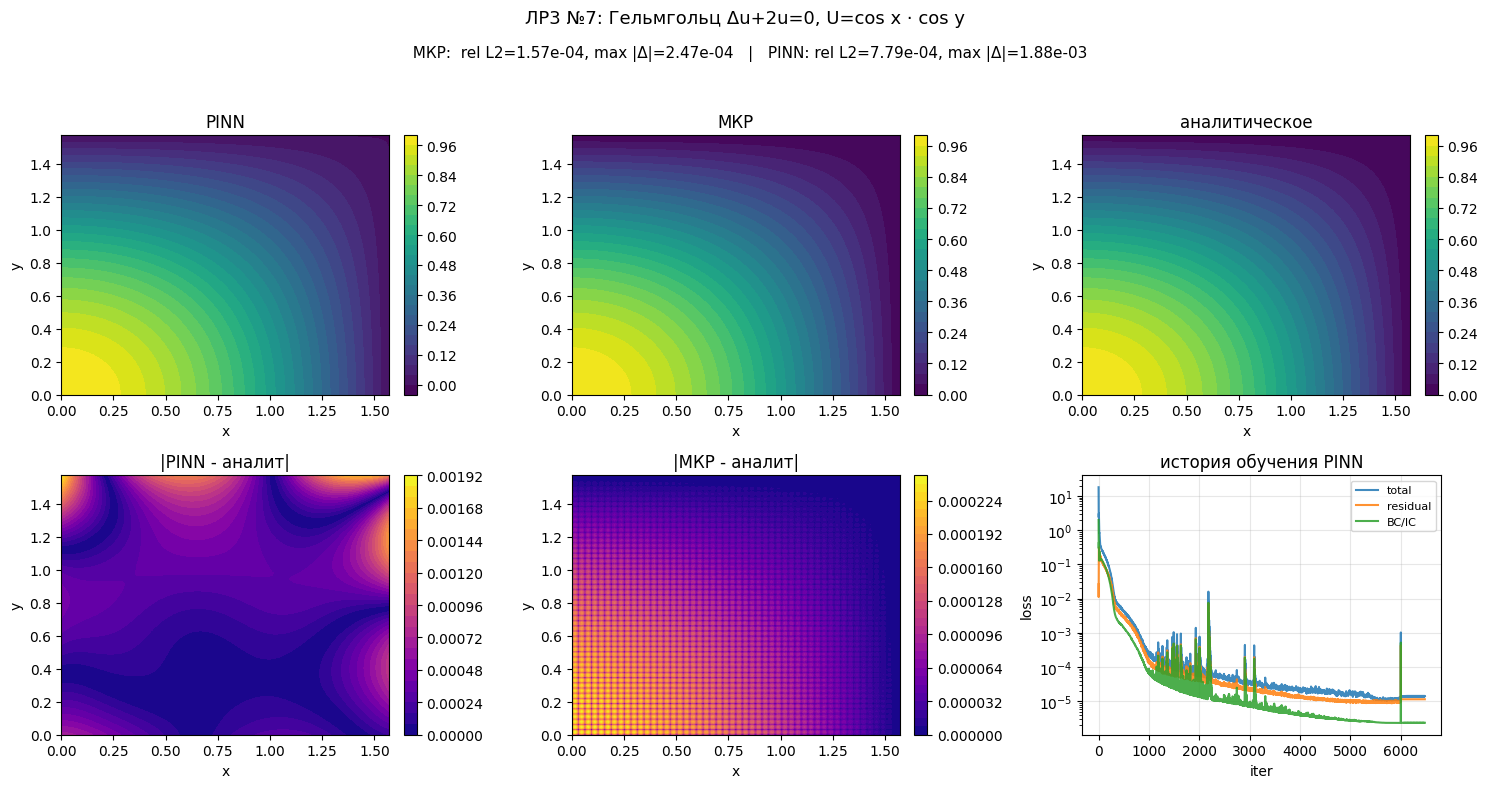


  ЛР3 №10: полное эллиптическое, U=e^{-x-y}cos x cos y
  PDE: Δu + 2u_x + 2u_y + 4u = 0
--- МКР ---
  МКР-эллиптика: nx=81, ny=81, hx=0.01963, hy=0.01963
  МКР время: 0.27s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=3000 random)


Adam:  25%|██▌       | 2006/8000 [00:59<02:54, 34.44it/s]

   2000 | L=1.84e-04 | res=8.55e-05 | cond=9.86e-05


Adam:  50%|█████     | 4006/8000 [01:55<01:57, 34.08it/s]

   4000 | L=4.70e-05 | res=2.88e-05 | cond=1.82e-05


Adam:  75%|███████▌  | 6007/8000 [02:51<00:53, 37.13it/s]

   6000 | L=1.35e-05 | res=8.78e-06 | cond=4.69e-06


Adam: 100%|██████████| 8000/8000 [03:46<00:00, 35.31it/s]


   8000 | L=8.71e-06 | res=6.07e-06 | cond=2.64e-06
L-BFGS (max 2500)
  L-BFGS   200 | L=2.79e-06
  L-BFGS   400 | L=2.79e-06
  L-BFGS   600 | L=2.79e-06
Done 251.7s | res=2.55e-06 | cond=2.38e-07 | total=2.79e-06
  PINN время: 251.67s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 5.262e-05   Max |Δ|: 3.009e-05
  PINN:   Rel L2: 5.595e-04   Max |Δ|: 6.220e-04


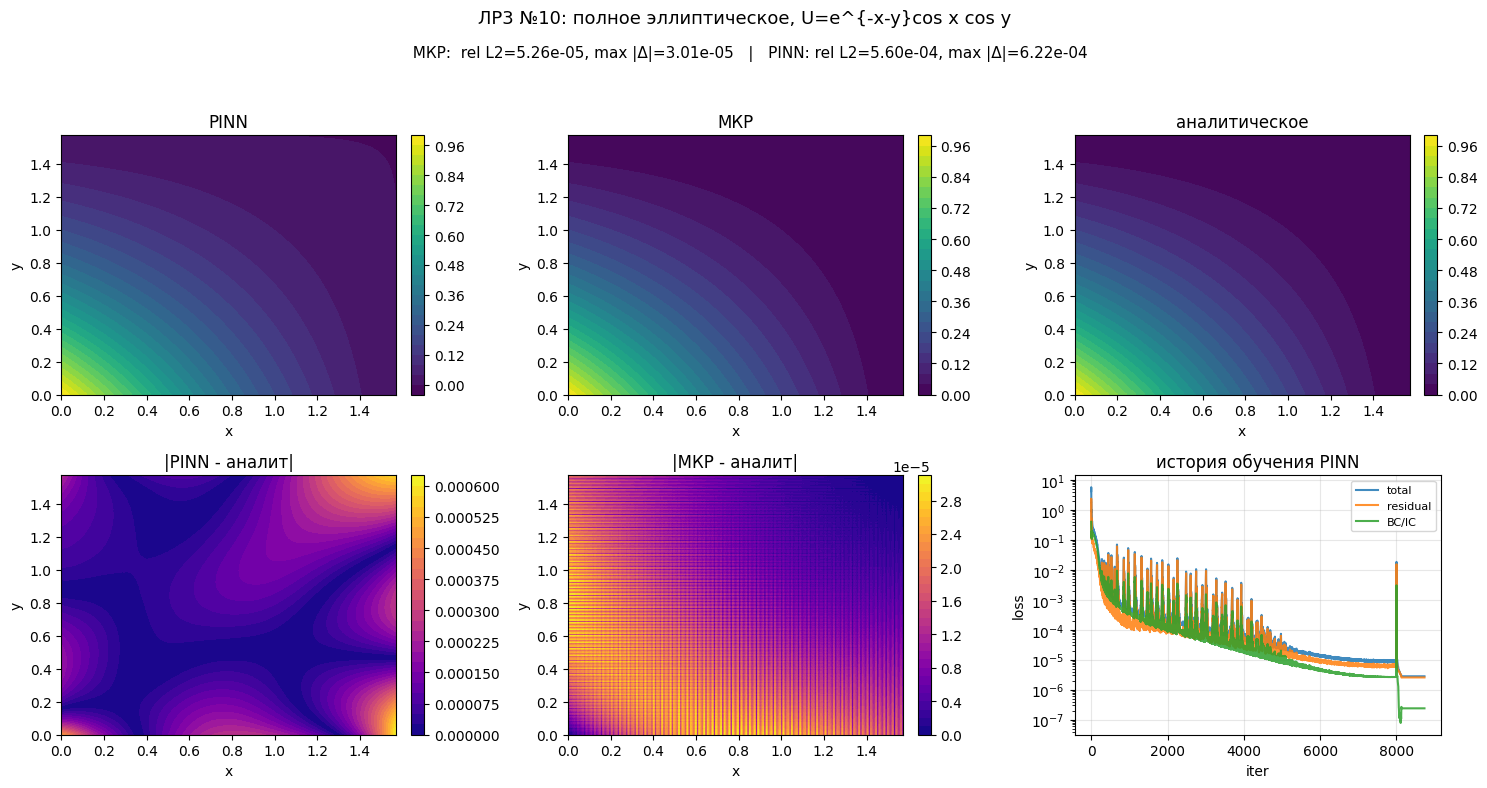

In [4]:
from problems.lr3_elliptic_2d import LR3_TASKS

lr3_results = []
for task in LR3_TASKS:
    res = run_task(task, kind='elliptic_2d',
                   PINNSolver_cls=PINNSolver, device=DEVICE,
                   eval_n=200, verbose=True)
    lr3_results.append(res)
    collect_row(res, task['name'])
    plot_compare_2d(res, save_to=PLOTS / f"lr3_{task['name'][4:6].strip().replace(' ','_')}.png")

## 4. Параболика 2D+t

Задача 1 — изотропная 2D-диффузия + Дирихле (нестационарные).

Задача 5 — cos×sinh-мода + Нейман снизу + Дирихле сверху и по бокам.

Задача 9 — анизотропная диффузия + гармонический источник + смешанные ГУ.


  ЛР4 №1: 2D диффузия + Дирихле, μ₁=μ₂=1
  PDE: u_t = a·Δu, Дирихле на 4 сторонах
--- МКР ---
  МКР-параболика 2D (ADI): nx=41, ny=41, nt=201, hx=0.0785, hy=0.0785, τ=0.01
  МКР время: 1.01s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=4000 random)


Adam:  25%|██▌       | 2002/8000 [01:35<04:31, 22.13it/s]

   2000 | L=8.06e-04 | res=2.42e-05 | cond=9.32e-04


Adam:  50%|█████     | 4001/8000 [03:06<03:05, 21.51it/s]

   4000 | L=7.33e-05 | res=2.77e-06 | cond=4.47e-05


Adam:  75%|███████▌  | 6002/8000 [04:38<01:31, 21.85it/s]

   6000 | L=1.10e-05 | res=1.32e-06 | cond=8.53e-06


Adam: 100%|██████████| 8000/8000 [06:15<00:00, 21.28it/s]


   8000 | L=6.03e-06 | res=1.96e-06 | cond=4.13e-06
L-BFGS (max 2500)
  L-BFGS   200 | L=5.84e-06
  L-BFGS   400 | L=5.97e-06
Done 401.4s | res=2.18e-06 | cond=4.13e-06 | total=6.40e-06
  PINN время: 401.44s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 9.765e-04   Max |Δ|: 1.539e-03
  PINN:   Rel L2: 1.474e-03   Max |Δ|: 4.447e-03


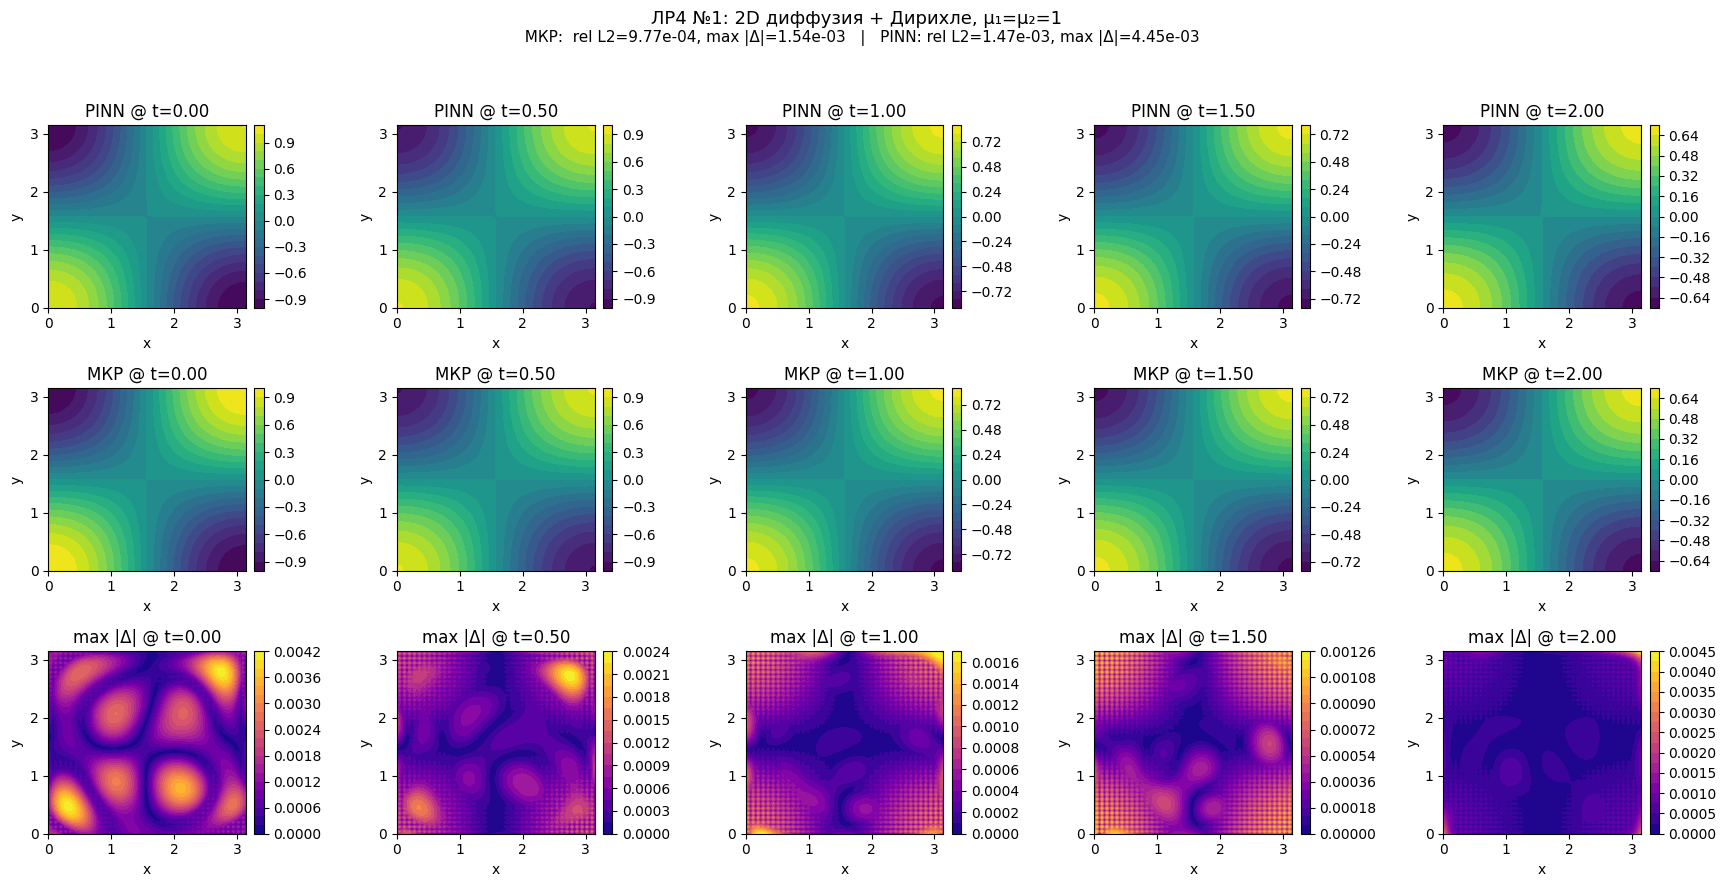


  ЛР4 №5: cos(2x)·sinh(y) + Нейман снизу
  PDE: u_t = a·Δu, U=cos(2x)·sinh(y)·exp(-3at)
--- МКР ---
  МКР-параболика 2D (ADI): nx=41, ny=41, nt=401, hx=0.0393, hy=0.0173, τ=0.005
  МКР время: 7.66s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=4000 random)


Adam:  25%|██▌       | 2001/8000 [01:39<05:01, 19.92it/s]

   2000 | L=2.06e-04 | res=5.40e-05 | cond=9.07e-05


Adam:  50%|█████     | 4002/8000 [03:18<03:46, 17.62it/s]

   4000 | L=2.38e-04 | res=1.15e-05 | cond=8.26e-05


Adam:  75%|███████▌  | 6003/8000 [04:55<01:32, 21.50it/s]

   6000 | L=6.37e-05 | res=6.06e-06 | cond=2.68e-05


Adam: 100%|██████████| 8000/8000 [06:30<00:00, 20.50it/s]


   8000 | L=2.18e-05 | res=6.10e-06 | cond=1.69e-05
L-BFGS (max 2500)
  L-BFGS   200 | L=2.24e-05
  L-BFGS   400 | L=3.35e-05
  L-BFGS   600 | L=3.32e-05
  L-BFGS   800 | L=3.52e-05
Done 439.8s | res=5.71e-06 | cond=1.84e-05 | total=4.19e-05
  PINN время: 439.80s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 5.091e-04   Max |Δ|: 5.777e-04
  PINN:   Rel L2: 3.825e-03   Max |Δ|: 7.259e-03


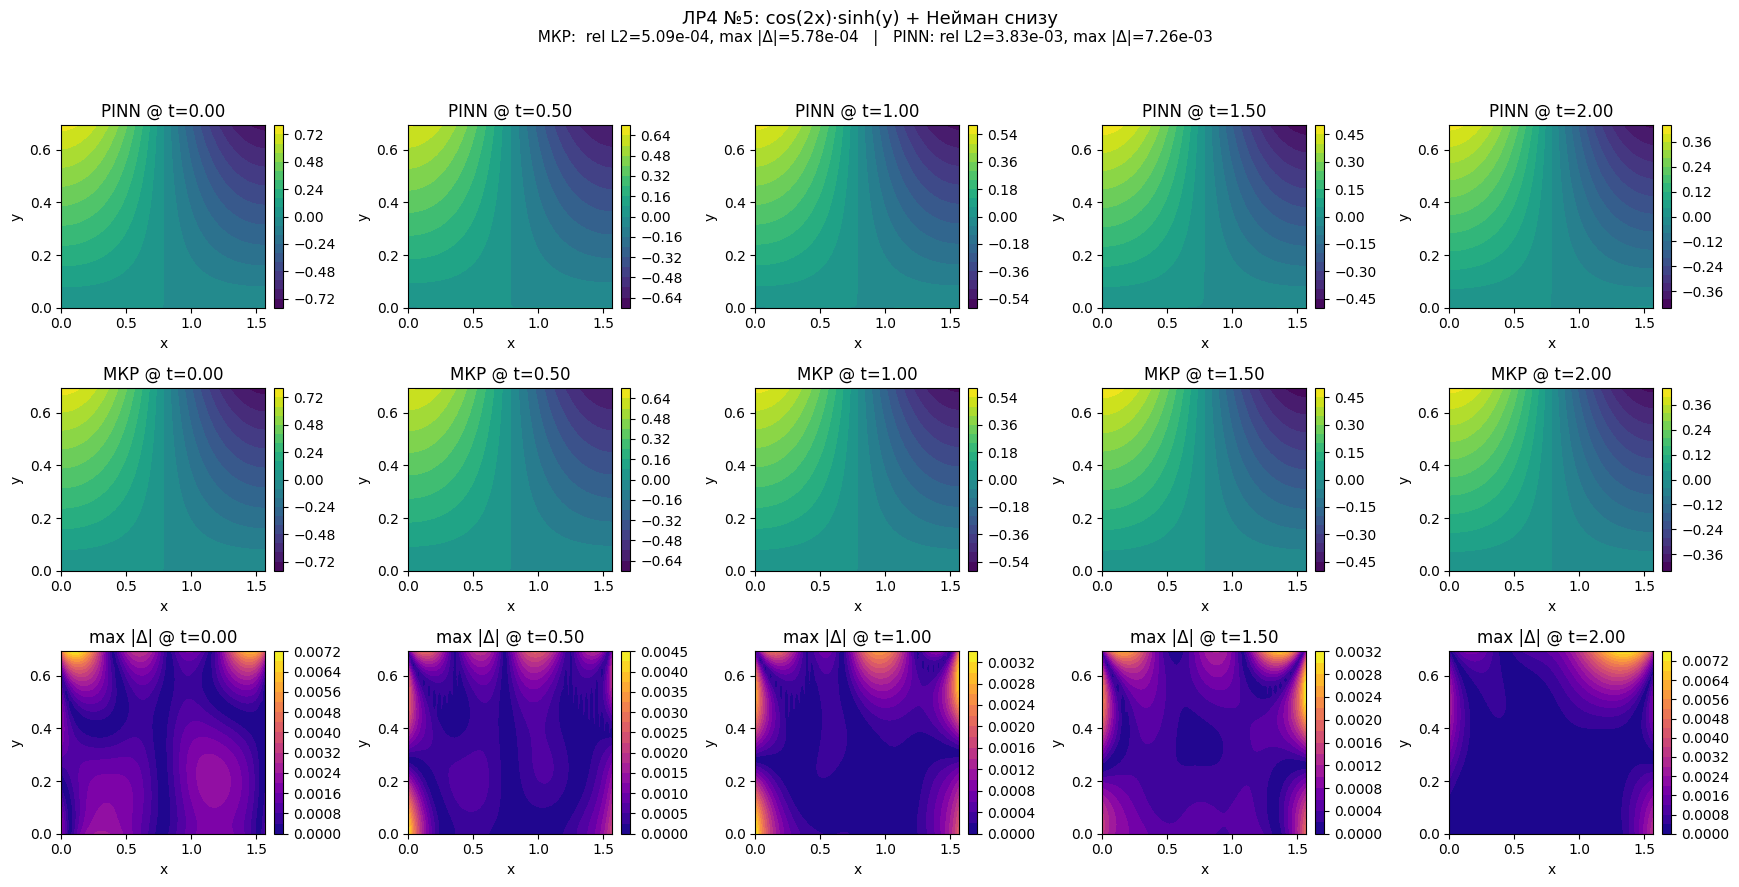


  ЛР4 №9: анизотропная диффузия + гармон. источник
  PDE: u_t = a u_xx + b u_yy + sin x · sin y · (μ cos μt + (a+b) sin μt)
--- МКР ---
  МКР-параболика 2D (ADI): nx=41, ny=61, nt=401, hx=0.0393, hy=0.0524, τ=0.00785
  МКР время: 8.57s
--- PINN ---
Adam (10000 ep, lr=0.001, coll=4000 random)


Adam:  20%|██        | 2001/10000 [01:33<06:14, 21.33it/s]

   2000 | L=4.89e-04 | res=6.21e-05 | cond=4.89e-04


Adam:  40%|████      | 4002/10000 [03:07<04:38, 21.51it/s]

   4000 | L=1.72e-04 | res=2.91e-05 | cond=1.32e-04


...

   6000 | L=9.15e-05 | res=2.14e-05 | cond=6.16e-05


Adam:  80%|████████  | 8002/10000 [06:29<01:35, 20.87it/s]

   8000 | L=5.58e-05 | res=1.86e-05 | cond=3.47e-05


Adam: 100%|██████████| 10000/10000 [08:06<00:00, 20.57it/s]


  10000 | L=6.21e-05 | res=2.17e-05 | cond=2.19e-05
L-BFGS (max 2500)
  L-BFGS   200 | L=5.25e-05
  L-BFGS   400 | L=4.62e-05
  L-BFGS   600 | L=4.81e-05
  L-BFGS   800 | L=4.44e-05
  L-BFGS  1000 | L=4.73e-05
Done 545.7s | res=2.12e-05 | cond=2.07e-05 | total=4.38e-05
  PINN время: 545.77s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 3.326e-04   Max |Δ|: 5.131e-04
  PINN:   Rel L2: 3.672e-03   Max |Δ|: 1.049e-02


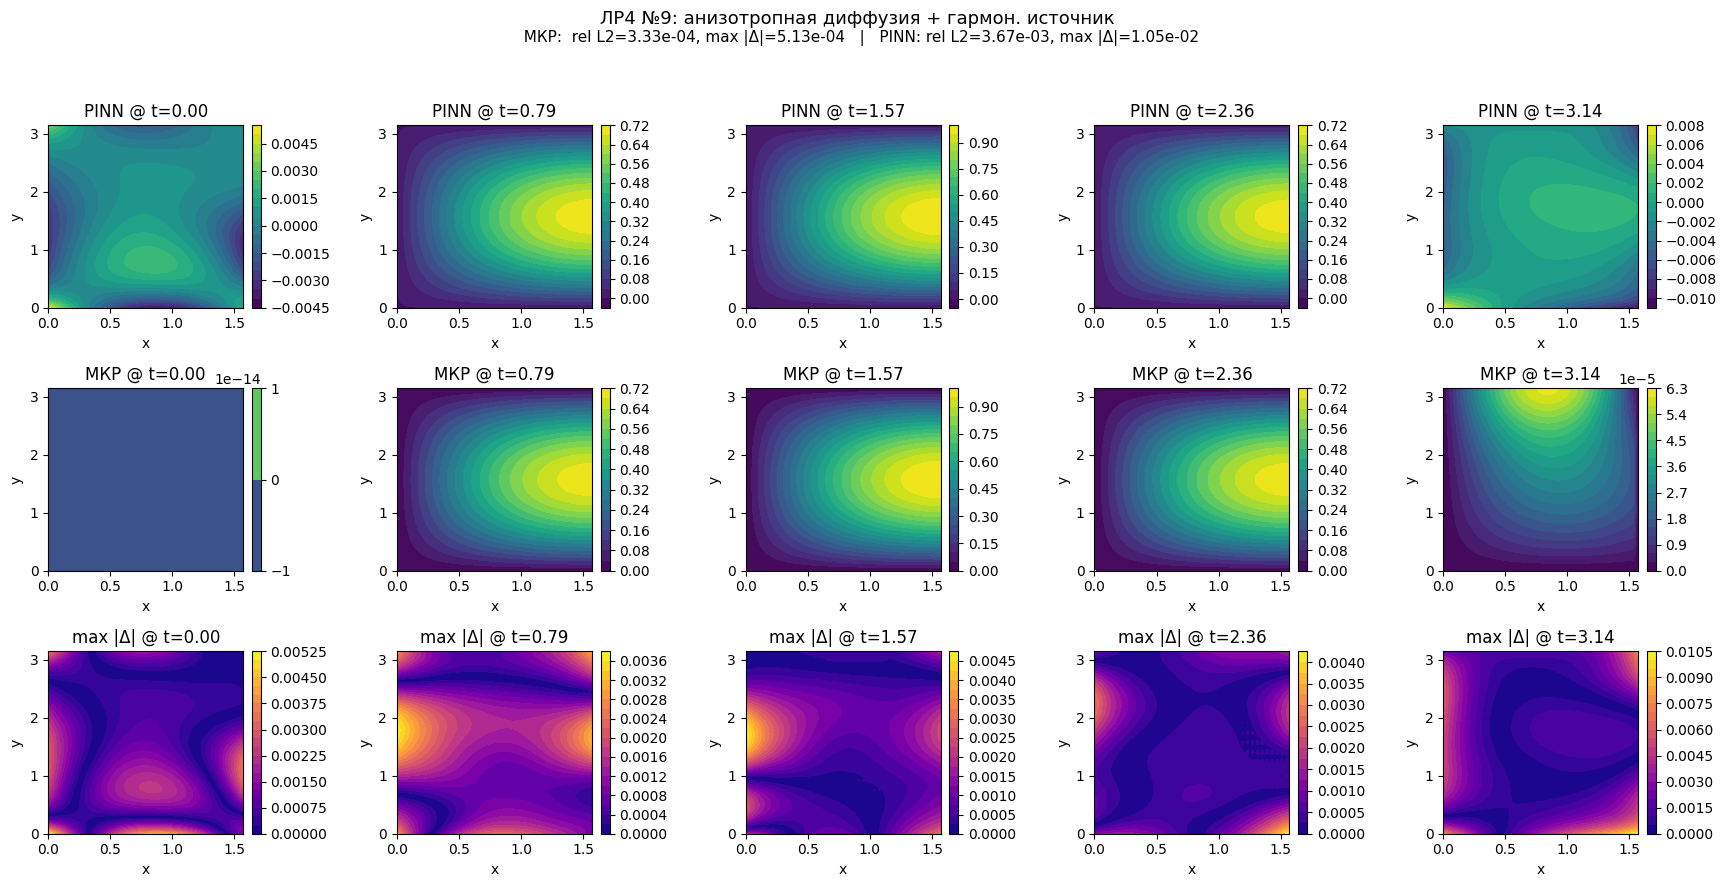

In [5]:
from problems.lr4_parabolic_2d import LR4_TASKS

lr4_results = []
for task in LR4_TASKS:
    res = run_task(task, kind='parabolic_2d_adi',
                   PINNSolver_cls=PINNSolver, device=DEVICE,
                   eval_n=80, verbose=True)
    lr4_results.append(res)
    collect_row(res, task['name'])
    plot_compare_2d_t_snapshots(
        res, save_to=PLOTS / f"lr4_{task['name'][4:6].strip().replace(' ','_')}.png")

## 5. Итоговая таблица сравнения

In [6]:
print_summary_table(all_results)

Задача                                           | МКР: rel L2 / max|Δ|         | время    | PINN: rel L2 / max|Δ|        | время   
------------------------------------------------------------------------------------------------------------------------------------
ЛР1 №2: диффузия + неодн. Дирихле                | 3.25e-05 / 9.84e-05          |    0.14s | 1.14e-04 / 4.32e-04          |   84.32s
ЛР1 №4: диффузия + нестац. Нейман                | 2.21e-04 / 2.36e-04          |    0.94s | 3.22e-04 / 4.29e-04          |  115.46s
ЛР1 №9: конвекция-диффузия + Робен               | 4.49e-04 / 1.44e-03          |    1.08s | 3.79e-02 / 1.08e-01          |  257.02s
ЛР2 №2: волновое + Робен (α=-1, β=1)             | 5.61e-05 / 1.21e-04          |    0.08s | 7.82e-02 / 4.94e-01          |  398.13s
ЛР2 №3: Клейн–Гордон + нестац. Дирихле           | 1.31e-05 / 1.47e-05          |    0.08s | 3.83e-03 / 6.68e-03          |  332.03s
ЛР2 №8: телеграфное (свободные затух. колебания) | 3.78e-05 / 7.05e-0

## 6. Сводный график: rel L2 всех задач

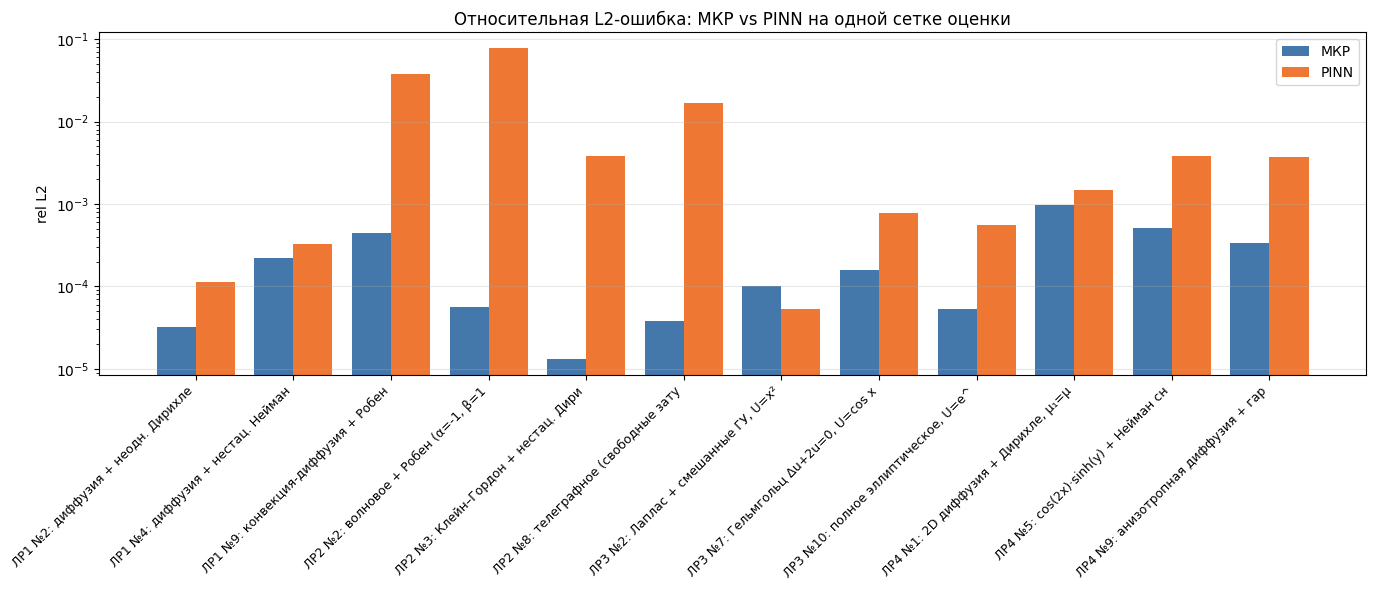

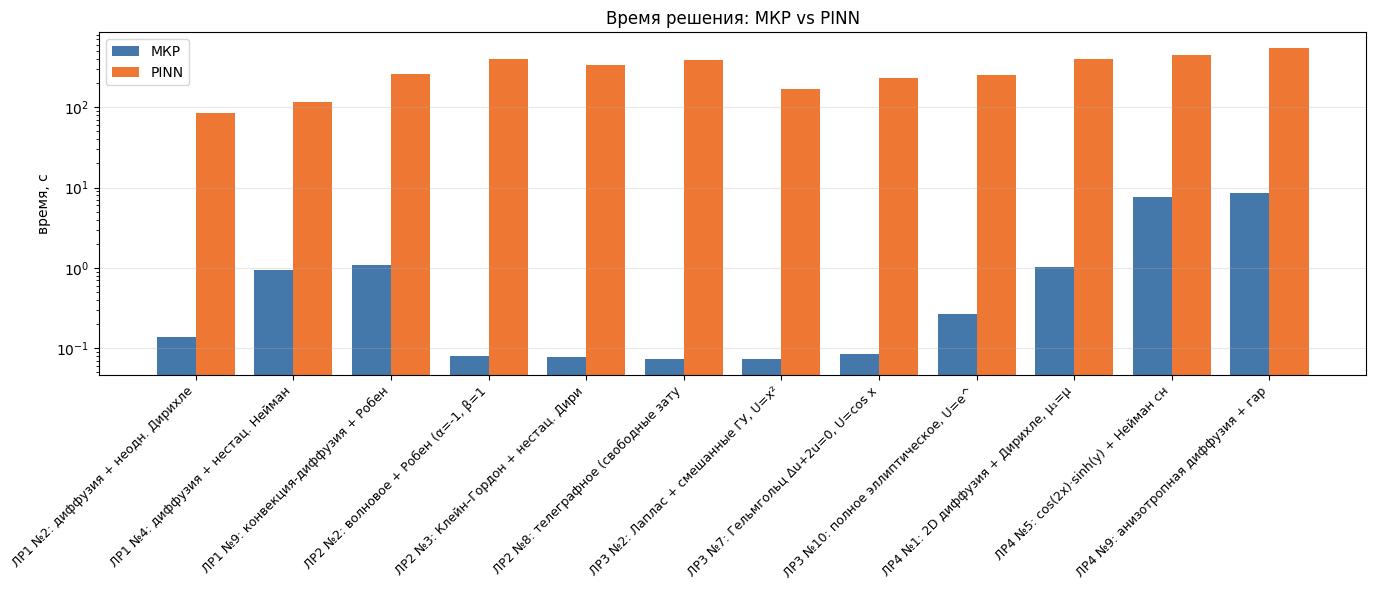

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

names = [r['name'][:35] for r in all_results]
fdm_rl = [r['fdm_err']['rel_l2'] if r.get('fdm_err') else np.nan
          for r in all_results]
pinn_rl = [r['pinn_err']['rel_l2'] if r.get('pinn_err') else np.nan
           for r in all_results]

x = np.arange(len(names))
width = 0.4
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, fdm_rl, width, label='МКР', color='#4477aa')
ax.bar(x + width/2, pinn_rl, width, label='PINN', color='#ee7733')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('rel L2')
ax.set_title('Относительная L2-ошибка: МКР vs PINN на одной сетке оценки')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('outputs/summary_rel_l2.png', dpi=120, bbox_inches='tight')
plt.show()

fdm_t = [r['fdm_time'] for r in all_results]
pinn_t = [r['pinn_time'] for r in all_results]
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, fdm_t, width, label='МКР', color='#4477aa')
ax.bar(x + width/2, pinn_t, width, label='PINN', color='#ee7733')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('время, с')
ax.set_title('Время решения: МКР vs PINN')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('outputs/summary_time.png', dpi=120, bbox_inches='tight')
plt.show()